In [1]:
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import plotly.express as px


from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.metrics import (
    silhouette_score, 
    r2_score,
)

import xgboost as xgb
from umap import UMAP
import shap

# =========================
# Custom utilities
# =========================
import utils.cross_validation as cval
import utils.umap_utils as uutil
import utils.exp_utils as exp

# =========================
# Optional helpers (math functions already included above)
# =========================
from math import radians, sin, cos, sqrt, asin
import math


def select_one_point_remove_buffer(df, 
                                   buffer_km=50, 
                                   lat_col='lat', lon_col='lon', 
                                   random_seed=None):
    """
    Select exactly ONE point and remove ALL other points within buffer_km.
    
    Parameters:
    - df: DataFrame with coordinates
    - buffer_km: radius in km to remove points (default: 50)
    - lat_col: latitude column name
    - lon_col: longitude column name
    - random_seed: random seed for reproducibility
    - method: 'random' or 'first' or index
    
    Returns:
    - selected_df: DataFrame with 1 selected point
    - remaining_df: DataFrame with points > buffer_km away (kept)
    - removed_df: DataFrame with points <= buffer_km away (removed)
    """
    
    if random_seed is not None:
        np.random.seed(random_seed)
    

    selected_idx = np.random.choice(df.index, 1, replace=False)[0]
 
    # Get selected point coordinates
    selected_point = df.loc[selected_idx]
    lat_sel = selected_point[lat_col]
    lon_sel = selected_point[lon_col]
    
    # Classify all points
    selected_points = [selected_idx]
    removed_points = []
    remaining_points = []
    
    for idx in df.index:
        if idx == selected_idx:
            continue
        
        # Calculate distance to selected point
        dist = haversine(lat_sel, lon_sel, 
                        df.loc[idx, lat_col], 
                        df.loc[idx, lon_col])
        
        if dist <= buffer_km:
            removed_points.append(idx)  # Too close → remove
        else:
            remaining_points.append(idx)  # Far enough → keep
    
    # Create DataFrames
    selected_df = df.loc[selected_points].copy()
    removed_df = df.loc[removed_points].copy()
    remaining_df = df.loc[remaining_points].copy()
    
    print(f"✓ Removed {len(removed_df)} points within {buffer_km}km")
    
    return selected_df, remaining_df, removed_df


def train_test_split_v3(df, random_key, n_points_to_select=2, buffer_km=100):

    # selected, remaining, removed = select_points_stratified(sub_df, 
    #     n_per_biome=n_points_to_select,
    #     buffer_km=buffer_km,
    #     lat_col='lat',
    #     lon_col='lon',
    #     random_seed=random_key
    # )
    selected, remaining, removed = select_one_point_remove_buffer(df, 
                                   buffer_km=50, 
                                   lat_col='lat', lon_col='lon', 
                                   random_seed=random_key)
    

    test = selected.drop(columns=['lat', 'lon', 'biome'])
    test_biomes=selected[['biome']]
    train= remaining.drop(columns=['lat', 'lon', 'biome'])

    y=['transformed npp'] 
    X_train=train.drop(columns=y+['PID'])

    y_train = train['transformed npp'].values

    X_test= test.drop(columns=y+['PID' ])
    y_test = test['transformed npp'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test, test_biomes, scaler


def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km"""
    R = 6371  # Earth's radius in km
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    return R * c

def plot_shap_with_polynomial_stats_v2(shap_values, X, div_f, div_s, degree=2, name=None):
    """Plot SHAP dependence with polynomial trend and statistics"""
    
    paired_vars = list(zip(div_f, div_s))

    colors_f = "#2E8B57"
    colors_f1="#66C2A5"
    colors_s = "#1F77B4"
    colors_s1= "#4C72B0"


    # Get data
    n_plots = len(div_f)
    n_cols = 2  # or any number you prefer
    n_rows = math.ceil(n_plots / n_cols)

    if shap_values.shape[0] < 500:
        n_samples = shap_values.shape[0]
    else:
        n_samples = 500

    # 2 rows x 2 cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes_flat = axes.flatten()  # flatten to iterate easily
    fig.subplots_adjust(hspace=0.6)  # increase from default ~0.2

    for ax, (f_var, s_var) in zip(axes_flat, paired_vars):

        if f_var == s_var:
             # ── Bottom x-axis: species diversity ──
            feature_idx = list(X.columns).index(s_var)
            shap_feature = shap_values[:, feature_idx].astype(np.float64)
            feature_values = X[s_var].values.astype(np.float64)

            if np.all(feature_values == 0):
                # Skip this axis - do nothing
                pass
            else:
                # Fit polynomial
                coeffs = np.polyfit(feature_values, shap_feature, degree)
                poly_func = np.poly1d(coeffs)
            
                # Calculate R²
                y_pred = poly_func(feature_values)
                ss_res = np.sum((shap_feature - y_pred) ** 2)
                ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
                r2 = 1 - (ss_res / ss_tot)

                indices = np.random.choice(len(feature_values), n_samples, replace=False)
                feature_values_sample = feature_values[indices]
                shap_feature_sample = shap_feature[indices]

                max_abs = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
                ax.set_ylim(-max_abs, max_abs)

                # # Scatter plot
                ax.scatter(feature_values_sample, shap_feature_sample, 
                                    alpha=0.5, s=20, c='lavender', linewidth=0.3)
                
            
                # Trend line
                x_smooth = np.linspace(feature_values.min(), feature_values.max(), 100)
                y_smooth = poly_func(x_smooth)
                ax.plot(x_smooth, y_smooth, c='slategray',  linewidth=2, 
                        label=f'Polynomial (degree {degree})\nR² = {r2:.4f}', zorder=10)
                ax.set_xlabel(s_var)
                ax.xaxis.set_label_position('top')  # Move label to top
                ax.tick_params(axis="x")
                ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

        else:
            # ── Bottom x-axis: species diversity ──
            feature_idx = list(X.columns).index(s_var)
            shap_feature = shap_values[:, feature_idx].astype(np.float64)
            feature_values = X[s_var].values.astype(np.float64)

            # Fit polynomial
            coeffs = np.polyfit(feature_values, shap_feature, degree)
            poly_func = np.poly1d(coeffs)
        
            # Calculate R²
            y_pred = poly_func(feature_values)
            ss_res = np.sum((shap_feature - y_pred) ** 2)
            ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
            r2 = 1 - (ss_res / ss_tot)

            indices = np.random.choice(len(feature_values), n_samples, replace=False)
            feature_values_sample = feature_values[indices]
            shap_feature_sample = shap_feature[indices]

            # # Scatter plot
            ax.scatter(feature_values_sample, shap_feature_sample, 
                                alpha=0.2, s=30, c=colors_s1, linewidth=0.3, zorder=1)
            

        
            # Trend line
            x_smooth1 = np.linspace(feature_values.min(), feature_values.max(), 100)
            y_smooth1 = poly_func(x_smooth1)
            ax.set_xlabel(s_var)
            ax.tick_params(axis="x")

            ax.plot(x_smooth1, y_smooth1, c=colors_s,  linewidth=2, 
                label=f'Polynomial (degree {degree})\nR² = {r2:.4f}', zorder=10)


            # ── Top x-axis: functional diversity ──

            ax_top = ax.twiny()
            feature_idx = list(X.columns).index(f_var)
            shap_feature = shap_values[:, feature_idx]
            feature_values = X[f_var].values

            # Fit polynomial
            coeffs = np.polyfit(feature_values, shap_feature, degree)
            poly_func = np.poly1d(coeffs)
        
            # Calculate R²
            y_pred = poly_func(feature_values)
            ss_res = np.sum((shap_feature - y_pred) ** 2)
            ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
            r2 = 1 - (ss_res / ss_tot)

            indices = np.random.choice(len(feature_values), n_samples, replace=False)
            feature_values_sample = feature_values[indices]
            shap_feature_sample = shap_feature[indices]


            ax_top.scatter(feature_values_sample, shap_feature_sample, 
                                alpha=0.2, s=30, c=colors_f1, linewidth=0.3, zorder=1)


            # Trend line
            x_smooth = np.linspace(feature_values.min(), feature_values.max(), 100)
            y_smooth = poly_func(x_smooth)



            ax_top.plot(x_smooth, y_smooth, c=colors_f,  linewidth=2, 
                    label=f'Polynomial (degree {degree})\nR² = {r2:.4f}', zorder=10)
            

            y_min = min(np.min(y_smooth), np.min(y_smooth1))
            y_max = max(np.max(y_smooth), np.max(y_smooth1))

            padding = 0.1 * (y_max - y_min)

            ax.set_ylim(y_min - padding, y_max + padding)

            ax_top.set_xlabel(f_var)
            ax_top.tick_params(axis="x")
            
            # max_abs = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
            # ax.set_ylim(-0.01, 0.01)

            # Reference line
            ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
            # Create legend handles
            legend_elements = [Patch(facecolor=colors_s, alpha=0.6, label='Species Diversity (sdiv)'),
                            Patch(facecolor=colors_f, alpha=0.6, label='Functional Diversity (fdiv)')]

            # Add legend to the figure
            fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=11)

            # Adjust layout to make room for legend
            plt.subplots_adjust(bottom=0.12)
    if name:
        plt.savefig(name, dpi=300, bbox_inches="tight")
    plt.show()

def plot_shap_with_polynomial_stats_v3(shap_values, X, features, biome=None, degree=2, name=None):
    """
    Plot SHAP dependence with polynomial trend and statistics.
    Single feature list, one plot per feature, no overlapping axes.
    """

    # colors = {
    #     'scatter':"#999CC2",
    #     'line':    "#3E47C6",
    # }
    # colors = {
    #     'scatter': "#F8C1F5",
    #     'line':    "#FE4CF5",
    # }
    colors = {
        'scatter': "lavender",
        'line':    "slategray",
    }
    n_plots = len(features)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)

    n_samples = min(shap_values.shape[0], 2000)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes_flat = np.array(axes).flatten()
    fig.subplots_adjust(hspace=0.5, wspace=0.4)

    for i, (ax, var) in enumerate(zip(axes_flat, features)):

        feature_values = X[var].values.astype(np.float64)
        feature_idx = list(X.columns).index(var)
        shap_feature = shap_values[:, feature_idx].astype(np.float64)

        # Skip if all zeros
        if np.all(feature_values == 0):
            ax.set_visible(False)
            continue

        # Sample
        indices = np.random.choice(len(feature_values), n_samples, replace=False)
        fv_sample = feature_values[indices]
        sv_sample = shap_feature[indices]

        # Polynomial fit on full data
        coeffs = np.polyfit(feature_values, shap_feature, degree)
        poly_func = np.poly1d(coeffs)

        # R²
        y_pred = poly_func(feature_values)
        ss_res = np.sum((shap_feature - y_pred) ** 2)
        ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        # Scatter
        ax.scatter(fv_sample, sv_sample,
                   alpha=0.9, s=2, c=colors['scatter'],
                   edgecolor='darkgray',
                   linewidth=0.3, zorder=1)

        # Trend line
        x_smooth = np.linspace(feature_values.min(), feature_values.max(), 200)
        y_smooth = poly_func(x_smooth)
        ax.plot(x_smooth, y_smooth,
                c=colors['line'], linewidth=2,
                zorder=10)

        y_min = min(np.min(y_smooth), np.min(y_smooth))
        y_max = max(np.max(y_smooth), np.max(y_smooth))

        padding = 0.3 * (y_max - y_min)

        ax.set_ylim(y_min - padding, y_max + padding)
        # Reference line
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.8)

        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel('SHAP value', fontsize=10)
        ax.set_title(f'{var}', fontsize=11, pad=8)
        ax.legend(fontsize=8, loc='best')

    # Hide unused axes
    for ax in axes_flat[n_plots:]:
        ax.set_visible(False)

    title = f'SHAP Dependence — {biome}' if biome else 'SHAP Dependence'
    fig.suptitle(title, fontsize=13, y=1.02)

    if name:
        plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.show()


/home/qli/Projects/env1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Essential Params and Dicts

color_map = {
    'Species Richness': 'grey',
    'Shannon Diversity': "#8040a0",
    "Raos_Q": 'darkolivegreen',
    "Simpson's Index":  "#cca9dd",
    'Functional_Evenness': "#94BC92"
}
biome_colors = {
    'Temperate broadleaf forests': "#4881BE",   # Sea Green (mid-tone green)
    'Temperate conifer forests':   "#016742",   # Very Dark Green (near-black green)
    'Temperate grasslands':        '#DAA520',   # Goldenrod (yellow-brown)
    'Xeric shrublands':             '#B5651D',   # Burnt Orange-Brown (desert)
    'Boreal and Tundra forests':    '#4169E1',   # Royal Blue (cool, distinct from green)
    'Mediterranean woodlands':      '#9ACD32',   # Yellow-Green (olive, warm-leaning)
    'Tropical':                     '#FF00FF',   # Magenta (maximally distinct, non-natural but unmistakable)
    'NaN':                          '#D3D3D3'    # Light Gray
}

with open("config/ex_config.yaml", "r") as f:
    config = yaml.safe_load(f)

biome_mapping = config["biome_mapping"]
random_key=config["random_key"]

biome_list=["Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
            "Xeric shrublands", "Boreal and Tundra forests", "Tropical",
            "Mediterranean woodlands"]

## Basic Global Explainability 


In [4]:
fd_df = pd.read_csv('data/final/final_dataset.csv')
PID_df= pd.read_csv('data/lookup/PID_location_all.csv')

fd_df=fd_df.merge(PID_df[['PID','lat','lon', 'biome']], on='PID', how='left')

fd_df.dropna(subset=['transformed npp', 'Raos_Q', 'Functional_Evenness', 'Soil Moisture',
                    'Species Richness', 'Shannon Diversity', "Simpson's Index", "pet_std"], inplace=True)
fd_df = fd_df[fd_df["treecover2000"] > 60]

fd_df.drop_duplicates(subset=['PID'], inplace=True)

ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]
#Preprocessing the data for Random forest regression

fd_df['biome'] = fd_df['biome'].map(biome_mapping) # Only run this once ! 

biome_dfs = {k: v for k, v in fd_df.groupby('biome')}

fd_df = fd_df[fd_df["WSCI"] != 0]


X=fd_df.drop(columns=['transformed npp','Functional_Richness', 'PID', 'lat', 'lon', 'biome', 'treecover2000'])
X1=fd_df.drop(columns=['transformed npp','Functional_Richness', 'PID', 'lat', 'lon','treecover2000'])
y=fd_df['transformed npp'].values
scaler= StandardScaler()
scaler.fit_transform(X)
X = pd.DataFrame(
    X,
    columns=scaler.feature_names_in_
)

model = xgb.XGBRegressor(**config["global"])
model.fit(X, y )

y_pred = model.predict(X)



In [5]:
result_df=pd.DataFrame({
    'PID': fd_df['PID'],
    'biome': fd_df['biome'],
    'y_true': y,
    'y_pred': y_pred,
    'lon': fd_df['lon'],
    'lat': fd_df['lat']
})

In [6]:
result_df['absolute_error'] = np.abs(result_df['y_true'] - result_df['y_pred'])

#### SHAP plots 


In [22]:
import matplotlib.pyplot as plt

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Data manipulation
import numpy as np
import pandas as pd
import math
import shap
from scipy.interpolate import UnivariateSpline
from matplotlib.lines import Line2D
def plot_shap_with_spline_stats_v4(
    shap_values,
    X,
    features,
    spline_degree=3,
    biome=None,
    n_cols=3,
    smoothing=None,
    name=None,
):
    """
    Plot SHAP dependence with smoothing splines and hexbin density.
    Each feature is plotted in its own subplot.
    """

    vmin = X["Annual Temp"].quantile(0.02)
    vmax = X["Annual Temp"].quantile(0.98)

    colors = {
        "line": "blue",
    }

    n_plots = len(features)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 5 * n_rows)
    )

    axes = np.array(axes).reshape(-1)
    fig.subplots_adjust(hspace=0.45, wspace=0.35)

    for ax, var in zip(axes, features):

        feature_idx = list(X.columns).index(var)


        feature_values = X[var].values.astype(float)
        shap_feature = shap_values[:, feature_idx].astype(float)

        # Skip empty variables
        if np.all(feature_values == 0):
            ax.set_visible(False)
            continue

        # -------------------------------
        # Fit smoothing spline
        # -------------------------------
        order = np.argsort(feature_values)

        x_sorted = feature_values[order]
        y_sorted = shap_feature[order]

        x_unique, inverse = np.unique(x_sorted, return_inverse=True)

        y_unique = np.zeros_like(x_unique)
        counts = np.zeros_like(x_unique)

        np.add.at(y_unique, inverse, y_sorted)
        np.add.at(counts, inverse, 1)

        y_unique /= counts

        k = max(1, min(spline_degree, len(x_unique) - 1))
        s = smoothing if smoothing is not None else len(x_unique)

        spline = UnivariateSpline(x_unique, y_unique, k=k, s=s)

        y_pred = spline(feature_values)

        ss_res = np.sum((shap_feature - y_pred) ** 2)
        ss_tot = np.sum((shap_feature - shap_feature.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot

        # -------------------------------
        # Plot limits
        # -------------------------------
        x_min = feature_values.min()
        x_max = feature_values.max()

        x_smooth = np.linspace(x_min, x_max, 300)
        y_smooth = spline(x_smooth)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(-0.05, 0.05)

        sc=ax.scatter(
            feature_values,
            shap_feature,
            alpha=0.08,
            vmin=vmin,
            vmax=vmax,
            s=10,
            cmap='coolwarm',
            c=X['Annual Temp'],
            linewidth=0.3,
            zorder=1,
        )
        
        # # -------------------------------
        # # Spline
        # # -------------------------------
        # ax.plot(
        #     x_smooth,
        #     y_smooth,
        #     color=colors["line"],
        #     linewidth=2.5,
        #     zorder=5,
        #     label=f"Spline (R² = {r2:.2f})",
        # )

        ax.axhline(
            0,
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.3,
        )

        ax.set_xlabel(var)
        ax.set_ylabel("SHAP value")
        ax.set_title(var)
        ax.legend(fontsize=8)

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    title = (
        f"SHAP Dependence — {biome}"
        if biome is not None
        else "SHAP Dependence"
    )

    norm = Normalize(
        vmin=X["Annual Temp"].min(),
        vmax=X["Annual Temp"].max()
    )

    sm = ScalarMappable(
        cmap="coolwarm",
        norm=norm
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        fraction=0.03,
        pad=0.08,
    )

    cbar.set_label("Annual Temp")

    if name:
        fig.savefig(name, dpi=300, bbox_inches="tight")

    return fig


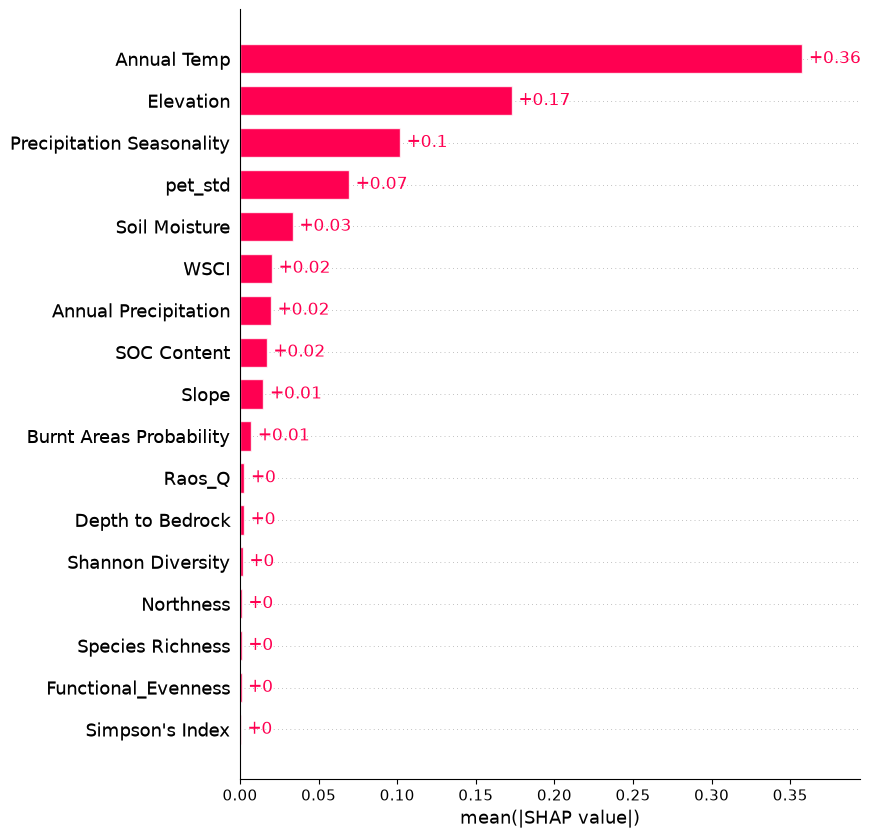

<Figure size 640x480 with 0 Axes>

In [8]:
explainer = shap.Explainer(model, approximate=True)

shap_vals = explainer.shap_values(X, approximate=True)
mean_shap = np.abs(shap_vals).mean(axis=0)
model_features = getattr(model, "feature_names_in_", X.columns)
shap_values = explainer(X, approximate=True )

shap.plots.bar(shap_values, max_display=len(X.columns))

plt.tight_layout()
plt.show()

shap_importance = pd.DataFrame({
    "feature": model_features,
    "mean_abs_shap": mean_shap
}).sort_values("mean_abs_shap", ascending=False)

all_shap_df = pd.DataFrame(
    shap_vals,
    columns=[f'shap_{col}' for col in X.columns],
    index=X.index
)

shap_df2 = pd.concat(
    [
        fd_df.loc[fd_df.index, ["PID", "lat", "lon" ]].reset_index(drop=True),
        all_shap_df.reset_index(drop=True)
    ],
    axis=1
)

diversity_vars_f = ['Raos_Q', 'Functional_Evenness', 'Species Richness']
diversity_vars_s =  ["Simpson's Index", 'Shannon Diversity','Species Richness']
diversity_vars = ['Raos_Q', 'Functional_Evenness', 'Species Richness'
                  ]


/tmp/ipykernel_828459/3094022659.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


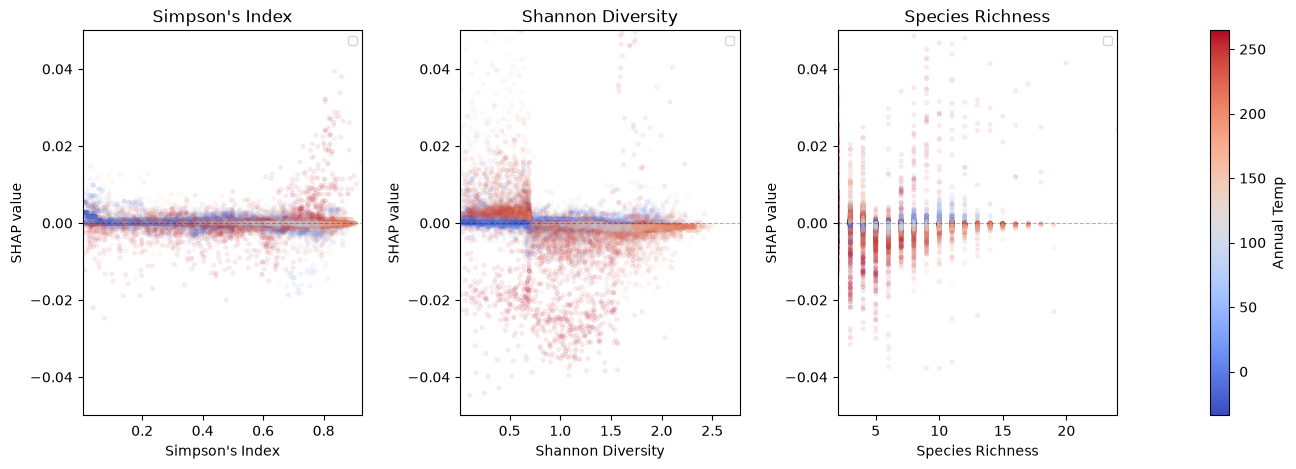

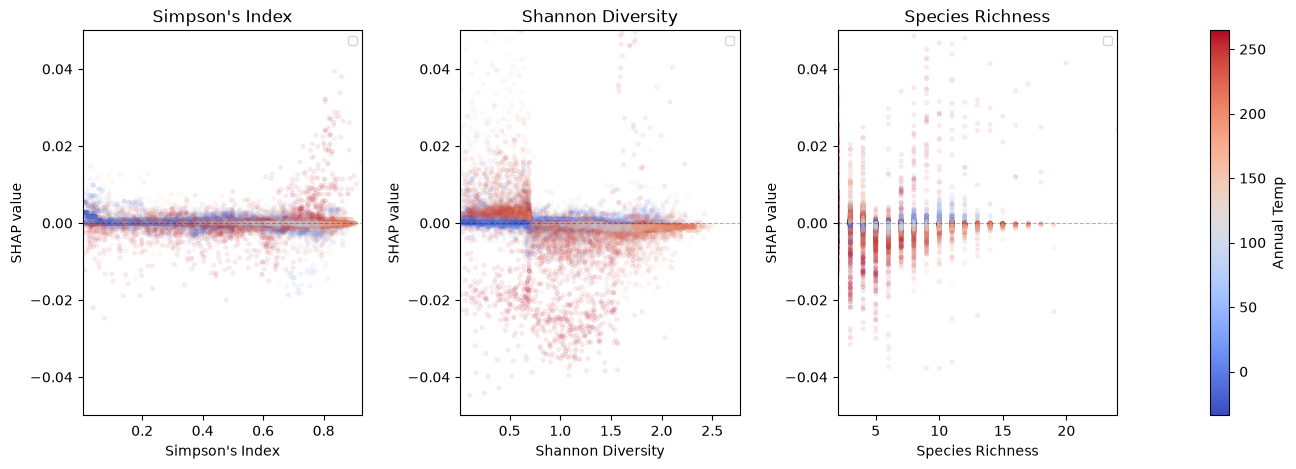

In [24]:
diversity_vars = ["Simpson's Index", 'Shannon Diversity', 'Species Richness']

plot_shap_with_spline_stats_v4(shap_vals, X1, diversity_vars)


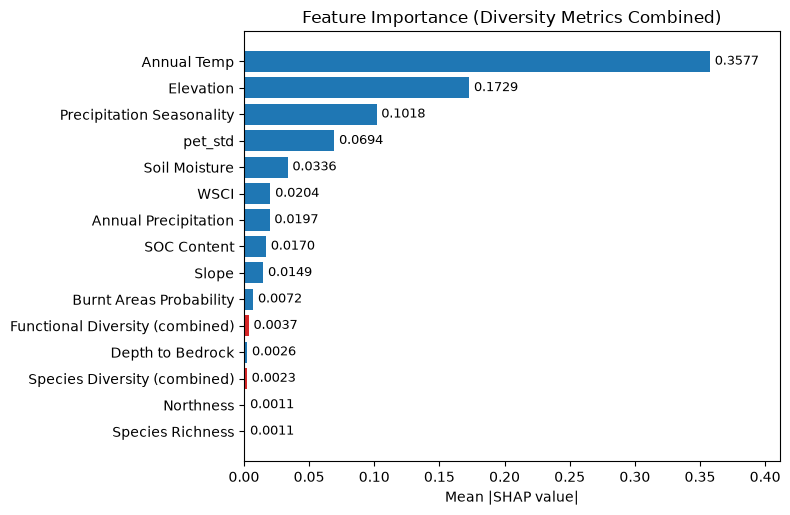

In [10]:
import matplotlib.pyplot as plt

diversity_vars_f = ['Raos_Q', 'Functional_Evenness']
diversity_vars_s = ["Simpson's Index", 'Shannon Diversity']

# Sum SHAP importance within each group
functional_sum = shap_importance.loc[
    shap_importance['feature'].isin(diversity_vars_f), 'mean_abs_shap'
].sum()

species_sum = shap_importance.loc[
    shap_importance['feature'].isin(diversity_vars_s), 'mean_abs_shap'
].sum()

# Remove all individual diversity variables (union of both lists) from the table
all_diversity_vars = set(diversity_vars_f) | set(diversity_vars_s)
shap_importance_combined = shap_importance[
    ~shap_importance['feature'].isin(all_diversity_vars)
].copy()

# Add the two combined rows
summary_rows = pd.DataFrame({
    'feature': ['Functional Diversity (combined)', 'Species Diversity (combined)'],
    'mean_abs_shap': [functional_sum, species_sum]
})

shap_importance_combined = pd.concat(
    [shap_importance_combined, summary_rows], ignore_index=True
).sort_values('mean_abs_shap', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(8, max(4, len(shap_importance_combined) * 0.35)))
colors = ['#d62728' if f in summary_rows['feature'].values else '#1f77b4'
          for f in shap_importance_combined['feature']]

bars = ax.barh(
    shap_importance_combined['feature'],
    shap_importance_combined['mean_abs_shap'],
    color=colors
)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance (Diversity Metrics Combined)')

# Add value labels at the end of each bar
max_val = shap_importance_combined['mean_abs_shap'].max()
for bar, value in zip(bars, shap_importance_combined['mean_abs_shap']):
    ax.text(
        bar.get_width() + max_val * 0.01,  # small offset past the bar end
        bar.get_y() + bar.get_height() / 2,
        f'{value:.4f}',
        va='center',
        ha='left',
        fontsize=9
    )

# Give a bit of extra room on the right so labels aren't clipped
ax.set_xlim(0, max_val * 1.15)

plt.tight_layout()
plt.show()


#### UMapping


In [11]:

s_2d = UMAP(
    n_neighbors=30,
    min_dist=0.05,
    metric="cosine",   # sometimes faster + better for SHAP
    n_jobs=-1,
    low_memory=True
).fit_transform(shap_vals)

In [12]:

def plot_umap_by_features(s_2d, X, features, cmap='viridis', name=None):
    ncols = 2
    nrows = (len(features) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = axes.flatten()
    fig.subplots_adjust(hspace=0.5, wspace=0.4)

    for ax, feat in zip(axes_flat, features):
        sc = ax.scatter(
            s_2d[:, 0], s_2d[:, 1],
            c=X[feat].values,
            cmap=cmap,
            s=5,
            alpha=0.6
        )
        plt.colorbar(sc, ax=ax, label=feat)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.spines[['right', 'top']].set_visible(False)

    # Hide unused axes
    for ax in axes_flat[len(features):]:
        ax.set_visible(False)

    plt.suptitle("UMAP of SHAP values coloured by feature", fontsize=13, y=1.02)
    if name:
        plt.savefig(name, dpi=150, bbox_inches="tight")
    plt.show()

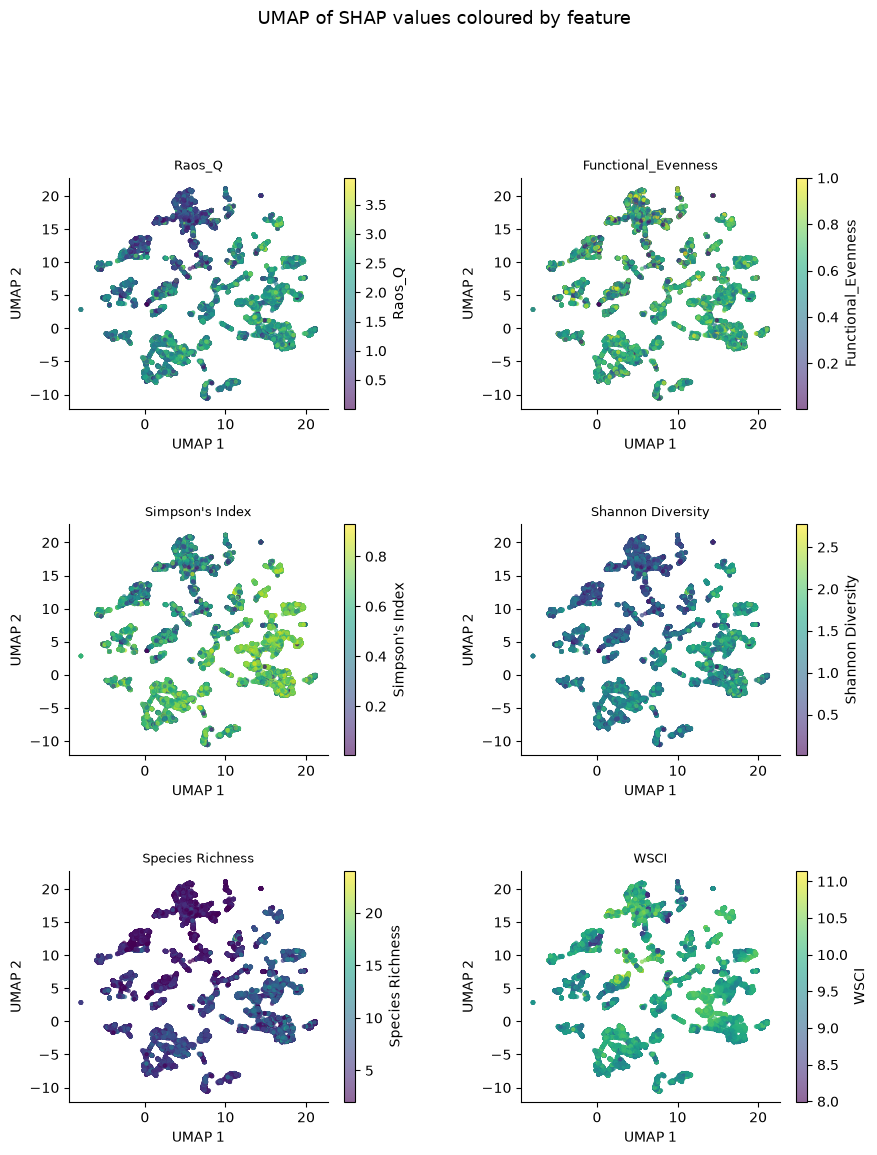

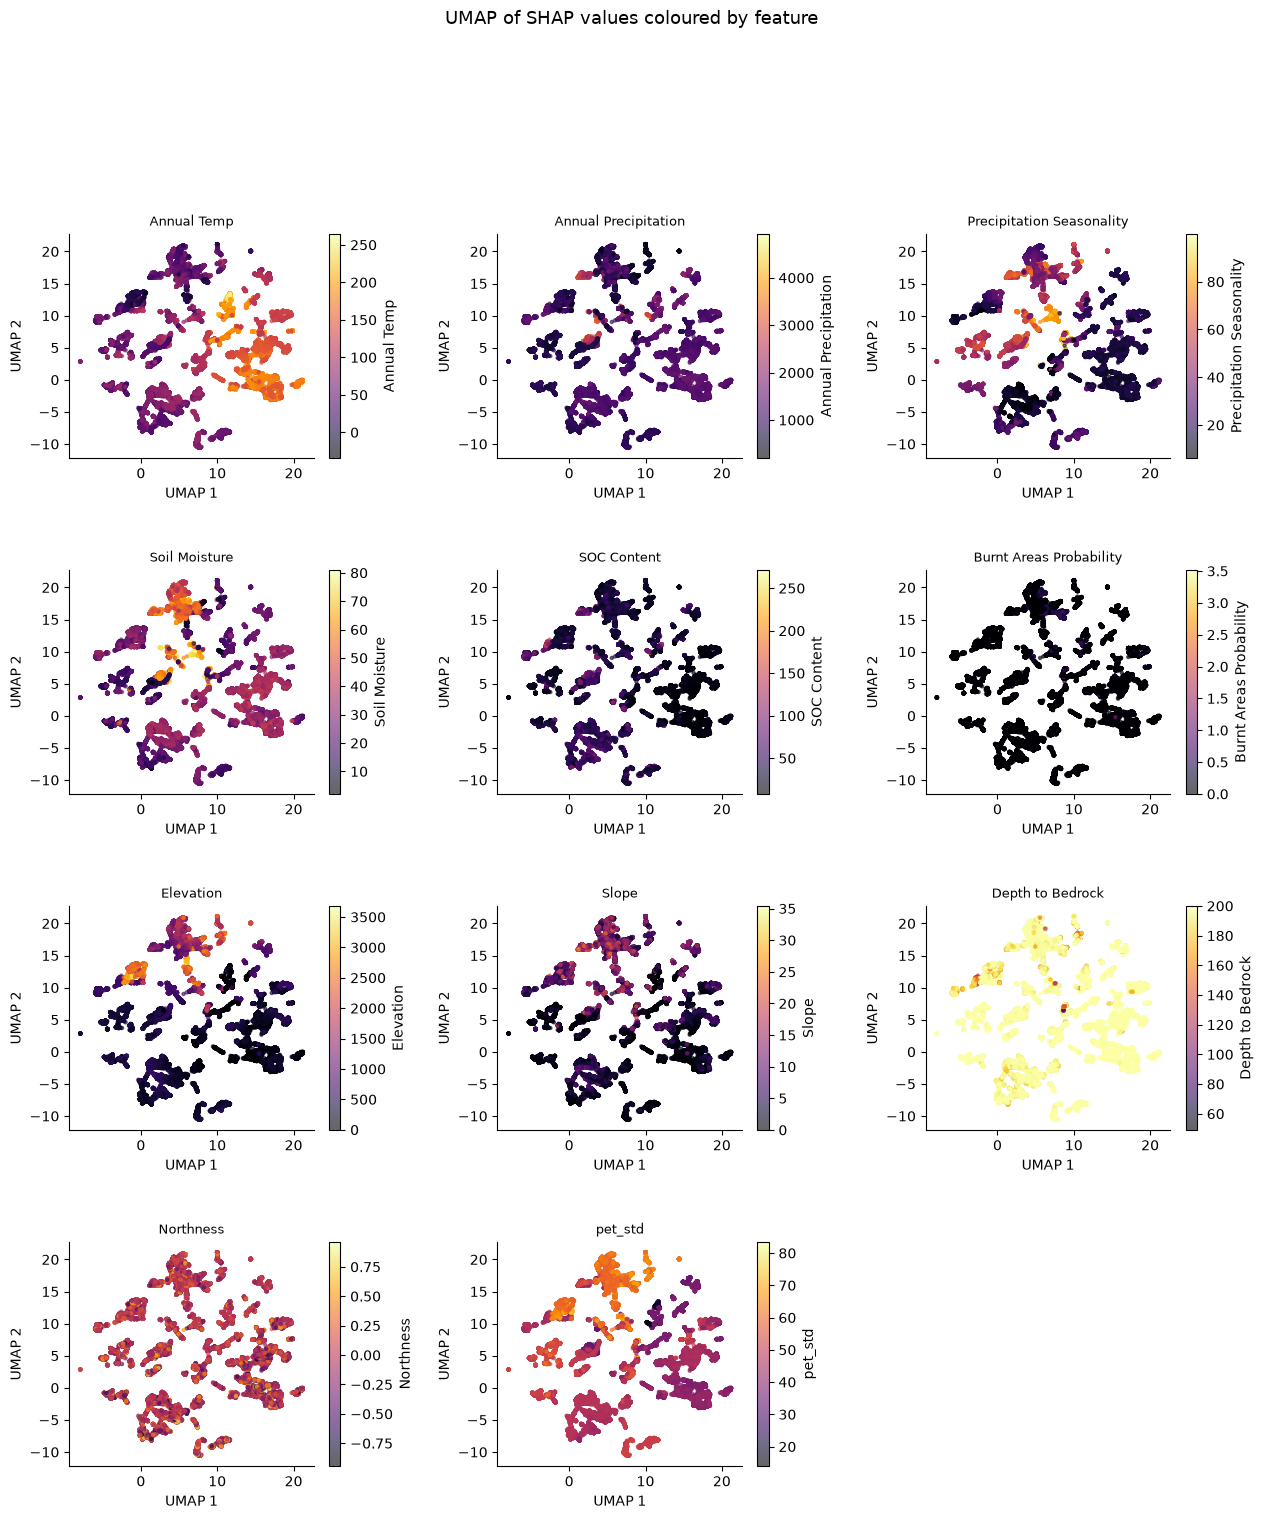

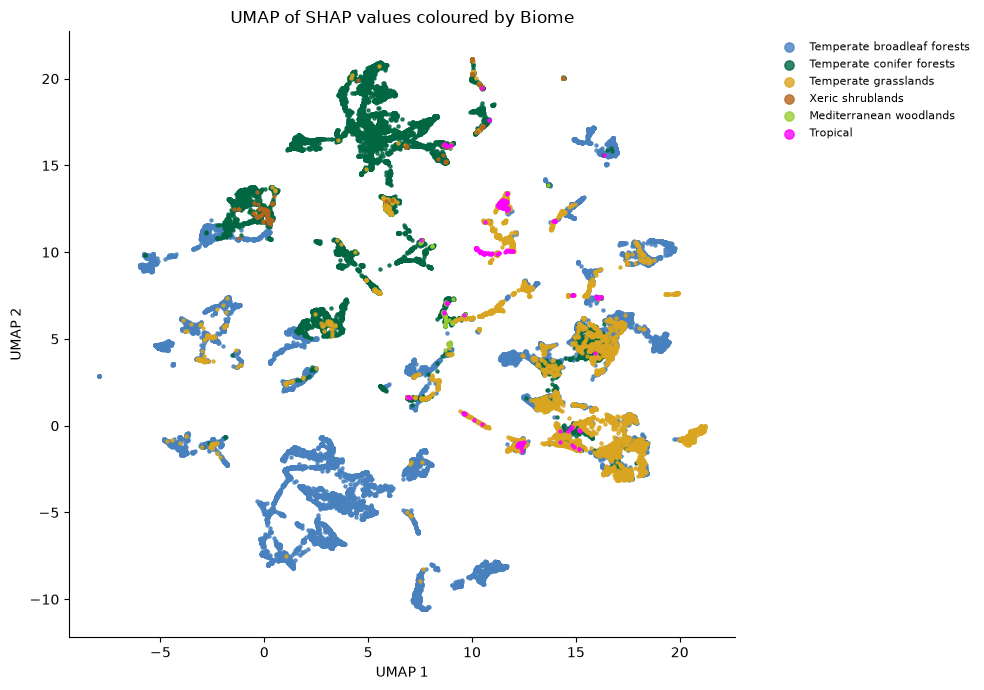

In [13]:
feature_list = ['Raos_Q','Functional_Evenness',"Simpson's Index", 'Shannon Diversity', 
                'Species Richness','WSCI']

plot_umap_by_features(s_2d, fd_df, cmap="viridis", features=feature_list,)

feature_list1 = [feat for feat in X.columns if feat not in feature_list]

uutil.plot_umap_by_features(s_2d, fd_df, cmap="inferno", features=feature_list1, name=None)
uutil.plot_umap_biome(s_2d, fd_df, biome_colors, name="figures/umap_shap_biome.png")

In [14]:
biome_labels = fd_df['biome'].values

est = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')

for feat in feature_list :
    vals = fd_df[feat].values.reshape(-1, 1)
    labels = est.fit_transform(vals).astype(int).flatten()
    score = silhouette_score(s_2d, labels, sample_size=10000, random_state=42)
    print(f"{feat:30s} Silhouette: {score:.3f}")


est2 = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile',  quantile_method='averaged_inverted_cdf')

results = []

for biome in biome_list:
    mask = biome_labels == biome
    X_filtered = X[mask]
    s_2d_filtered = s_2d[mask]
    n = len(s_2d_filtered)
    
    # Skip biomes with too few samples
    if n < 50:
        print(f"Skipping {biome}: only {n} samples")
        continue
    
    for feat in feature_list:
        try:
            vals = X_filtered[feat].values.reshape(-1, 1)
            labels = est2.fit_transform(vals).astype(int).flatten()
            
            # Skip if only one class after binning
            if len(set(labels)) < 2:
                continue
                
            score = silhouette_score(s_2d_filtered, labels, random_state=42)
            results.append({'biome': biome, 'feature': feat, 'silhouette': score, 'n': n})
            
        except Exception as e:
            print(f"Failed {biome} / {feat}: {e}")

# Summarise as a readable table
results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='biome', columns='feature', values='silhouette').round(3)


Raos_Q                         Silhouette: 0.085
Functional_Evenness            Silhouette: 0.003
Simpson's Index                Silhouette: 0.067
Shannon Diversity              Silhouette: 0.084
Species Richness               Silhouette: 0.102
WSCI                           Silhouette: 0.018
Skipping Boreal and Tundra forests: only 0 samples


In [15]:
biome_labels = fd_df['biome'].values

est = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')

for feat in feature_list :
    vals = fd_df[feat].values.reshape(-1, 1)
    labels = est.fit_transform(vals).astype(int).flatten()
    score = silhouette_score(s_2d, labels, sample_size=10000, random_state=42)
    print(f"{feat:30s} Silhouette: {score:.3f}")


Raos_Q                         Silhouette: 0.085
Functional_Evenness            Silhouette: 0.003
Simpson's Index                Silhouette: 0.067
Shannon Diversity              Silhouette: 0.084
Species Richness               Silhouette: 0.102
WSCI                           Silhouette: 0.018


#### Shap on a Map! 


In [16]:
shap_df2.to_csv('data/final/global_shap_values.csv', index=False)

In [17]:
# Make this compatible with global model not just local

eco=pd.read_csv('data/lookup/PID_with_ecoregion.csv')
biome_df=fd_df[['PID', 'biome', 'transformed npp', 'lon', 'lat', 'WSCI']]

subset_shap=shap_df2[[ 'PID','lon', 'lat','shap_Raos_Q', 'shap_Functional_Evenness',
                 'shap_Species Richness', 'shap_Shannon Diversity', 'shap_Simpson\'s Index', 'shap_Species Richness']]

In [18]:
# Identify the feature columns (everything except PID)
feature_cols = [c for c in subset_shap.columns if c not in['PID', 'lon', 'lat']]

# Find the column name with the largest SHAP value for each row
top_feature_df = pd.DataFrame({
    'PID': subset_shap['PID'],
    'top_feature': subset_shap[feature_cols].idxmax(axis=1),
    'lon': subset_shap['lon'],
    'lat': subset_shap['lat']
})



In [19]:
subset_shap2=subset_shap[['PID']]

subset_shap2["shap_Functional_Diversity"] = (
    subset_shap["shap_Functional_Evenness"] +
    subset_shap["shap_Raos_Q"]
)

subset_shap2["shap_Species_Diversity"] = (
    subset_shap["shap_Simpson's Index"] +
    subset_shap["shap_Shannon Diversity"]
)

In [20]:
eco_df = pd.merge(subset_shap2, eco, on='PID', how='left')
eco = eco.merge(ecoregions, on='ECO_NAME', how='left')

biome_df = biome_df.merge(eco, on='PID', how='left')

shap_cols = [col for col in eco_df.columns if col.startswith("shap_")]

# Mean SHAP values per ecoregion
eco_shap_mean = eco_df.groupby("ECO_NAME")[shap_cols].mean()
eco_shap_mean["dominant_feature"] = eco_shap_mean.idxmax(axis=1)

# Count of plots (PIDs) per ecoregion
plot_counts = eco_df.groupby("ECO_NAME")["PID"].nunique()
eco_shap_mean["plot_count"] = plot_counts

# Filter to ecoregions with more than 10 plots
eco_shap_mean = eco_shap_mean[eco_shap_mean["plot_count"] > 100]

eco_df = eco_shap_mean.merge(ecoregions, left_index=True, right_on="ECO_NAME", how="left")

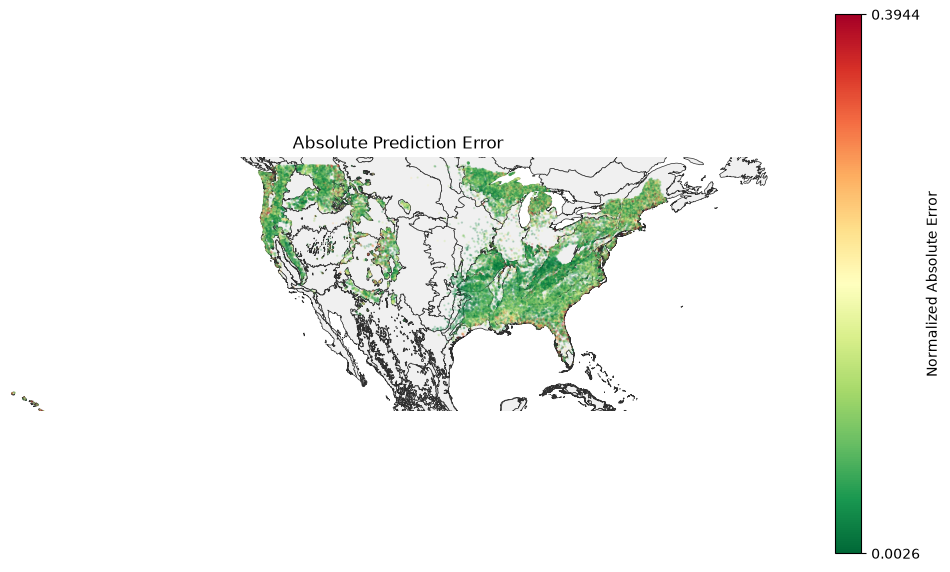

In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt

result_df["error_norm"] = (
    (result_df["absolute_error"] - result_df["absolute_error"].min()) /
    (result_df["absolute_error"].max() - result_df["absolute_error"].min())
)

result_gdf = gpd.GeoDataFrame(
    result_df,
    geometry=gpd.points_from_xy(result_df.lon, result_df.lat),
    crs="EPSG:4326"
)

ecoregions = gpd.read_file("data/Ecoregions/Ecoregions2017.shp")
result_gdf = result_gdf.to_crs(ecoregions.crs)

fig, ax = plt.subplots(figsize=(10, 8))

ecoregions.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="#2E2E2E",
    linewidth=0.5
)

vmin = result_gdf["error_norm"].quantile(0.02)
vmax = result_gdf["error_norm"].quantile(0.99)

result_gdf.plot(
    ax=ax,
    column="error_norm",
    cmap="RdYlGn_r",
    markersize=0.5,
    vmin=vmin,
    vmax=vmax,
    alpha=0.2,
    legend=True,
    legend_kwds={
        "label": "Normalized Absolute Error",
        "shrink": 0.7
    }
)

# --- Customize colorbar to show only Low / High ---
cbar = fig.axes[-1]  # the colorbar is the last axes added to the figure
cbar.set_yticks([vmin, vmax])
# cbar.set_yticklabels(["Low", "High"])

ax.set_title("Absolute Prediction Error")
ax.set_axis_off()

ax.set_xlim(-160, -50)
ax.set_ylim(20, 50)

plt.tight_layout()
plt.show()